# Blunder prediction model arena — fixed NN runtime version

This notebook extends the working pawn-loss blunder-prediction pipeline into a
larger model comparison.

It trains and compares:

1. **XGBoost**
2. **LightGBM**
3. **PyTorch MLP**
4. **Advanced PyTorch FT-Transformer-style tabular model**

This fixed version avoids the PyTorch models appearing stuck by:

- training PyTorch models on a controlled stratified row sample
- evaluating all models on the full validation/test sets
- printing per-epoch and per-batch progress
- capping internal neural-network validation size
- using smaller default NN epochs for feasible iteration

The task is:

> Given the current state of a game, predict whether the player to move will
> make a blunder within their next few own moves.

This version assumes engine evaluations are in **pawn units**, not centipawns.


## 0. Dependency notes

Add optional libraries from the project root:

```bash
uv add xgboost lightgbm torch optuna tqdm
```

`tqdm` is optional. The notebook also prints plain-text progress.


## 1. Main controls

The data defaults are set to the serious project target:

```python
N_GAMES_SAMPLE = 100_000
BLUNDER_PAWN_LOSS = 2.0
```

The PyTorch models are deliberately trained on a row sample. This is normal for
the comparison notebook: XGBoost/LightGBM are the full-data workhorses, while
the neural networks are experimental comparisons.

For a smoke test, use:

```python
N_GAMES_SAMPLE = 5_000
OPTUNA_TRIALS = 3
NN_TRAIN_MAX_ROWS = 50_000
NN_MAX_EPOCHS = 3
PERM_IMPORTANCE_MAX_ROWS = 5_000
```


In [1]:
import os

from pathlib import Path
import importlib.util
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  PrecisionRecallDisplay,
  RocCurveDisplay,
  average_precision_score,
  balanced_accuracy_score,
  classification_report,
  confusion_matrix,
  f1_score,
  roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Main data size control.
N_GAMES_SAMPLE = 100_000
RANDOM_GAME_SAMPLE = True

# Pawn-loss blunder definition.
MISTAKE_PAWN_LOSS = 1.0
BLUNDER_PAWN_LOSS = 2.0

# Predict blunder within this many own moves.
HORIZON_OWN_MOVES = 5

# Clip huge evals, e.g. possible mate encodings.
MAX_ABS_EVAL_PAWNS = 50.0

# Hyperparameter optimization controls.
RUN_HYPERPARAM_OPT = True
OPTUNA_TRIALS = 12
OPTUNA_TIMEOUT_SECONDS = None

# Neural-network controls.
# PyTorch models train on this many row-level samples, then evaluate on the
# full validation/test sets.
FORCE_TORCH_CPU = True
TORCH_NUM_THREADS = 1

os.environ["OMP_NUM_THREADS"] = str(TORCH_NUM_THREADS)
os.environ["MKL_NUM_THREADS"] = str(TORCH_NUM_THREADS)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(TORCH_NUM_THREADS)
os.environ["NUMEXPR_NUM_THREADS"] = str(TORCH_NUM_THREADS)

NN_TRAIN_MAX_ROWS = 300_000
NN_VALID_INTERNAL_MAX_ROWS = 50_000

NN_MAX_EPOCHS = 8
NN_BATCH_SIZE = 8192
NN_PATIENCE = 3
NN_LEARNING_RATE = 1e-3
NN_PROGRESS_EVERY_N_BATCHES = 25

# Transformer is cool but heavier. Set False if you want to skip it.
RUN_FT_TRANSFORMER = True

# Permutation importance controls.
RUN_PERMUTATION_IMPORTANCE = True
PERM_IMPORTANCE_MAX_ROWS = 20_000
PERM_IMPORTANCE_REPEATS = 3

pd.set_option("display.max_columns", 150)


## 2. Optional dependency checks


In [2]:
def has_package(name):
  return importlib.util.find_spec(name) is not None


HAS_XGBOOST = has_package("xgboost")
HAS_LIGHTGBM = has_package("lightgbm")
HAS_TORCH = has_package("torch")
HAS_OPTUNA = has_package("optuna")
HAS_TQDM = has_package("tqdm")

print("Optional package availability")
print("xgboost :", HAS_XGBOOST)
print("lightgbm:", HAS_LIGHTGBM)
print("torch   :", HAS_TORCH)
print("optuna  :", HAS_OPTUNA)
print("tqdm    :", HAS_TQDM)

if not HAS_XGBOOST:
  print("Missing xgboost. Install with: uv add xgboost")

if not HAS_LIGHTGBM:
  print("Missing lightgbm. Install with: uv add lightgbm")

if not HAS_TORCH:
  print("Missing torch. Install with: uv add torch")

if not HAS_OPTUNA:
  print("Missing optuna. Hyperparameter optimization will be skipped.")
  print("Install with: uv add optuna")


Optional package availability
xgboost : True
lightgbm: True
torch   : True
optuna  : True
tqdm    : True


## 3. Locate project root and load data


In [3]:
def find_project_root(start=None):
  if start is None:
    start = Path.cwd()

  start = Path(start).resolve()

  for path in [start, *start.parents]:
    has_pyproject = (path / "pyproject.toml").exists()
    has_data = (path / "data").exists()

    if has_pyproject and has_data:
      return path

  raise FileNotFoundError(
    "Could not find project root. Run from the project root "
    "or from a subdirectory such as scratch/."
  )


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed" / "lichess-2017-05-eval-all"

GAMES_PATH = DATA_DIR / "games.parquet"
PLIES_PATH = DATA_DIR / "plies.parquet"
FEATURES_PATH = DATA_DIR / "features.parquet"
DICT_PATH = DATA_DIR / "feature_dictionary.csv"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

for path in [GAMES_PATH, PLIES_PATH, FEATURES_PATH, DICT_PATH]:
  print(f"{path.name:24s} exists={path.exists()}")


Project root: /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder
Data dir:     /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/lichess-2017-05-eval-all
games.parquet            exists=True
plies.parquet            exists=True
features.parquet         exists=True
feature_dictionary.csv   exists=True


In [4]:
games = pd.read_parquet(GAMES_PATH)
plies = pd.read_parquet(PLIES_PATH)
features = pd.read_parquet(FEATURES_PATH)

if DICT_PATH.exists():
  feature_dict = pd.read_csv(DICT_PATH)
else:
  feature_dict = pd.DataFrame()

print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("feature_dict:", feature_dict.shape)


games: (957369, 17)
plies: (61361243, 39)
features: (957369, 80)
feature_dict: (6, 5)


## 4. Inspect schema and detect columns

If auto-detection guesses wrong, fill in `COLUMN_OVERRIDES`.


In [5]:
print("games columns")
display(pd.DataFrame({"column": games.columns}))

print("plies columns")
display(pd.DataFrame({"column": plies.columns}))

print("features columns")
display(pd.DataFrame({"column": features.columns}))

if len(feature_dict) > 0:
  print("feature dictionary preview")
  display(feature_dict.head(80))


games columns


,column
0,game_index
1,event
2,site
3,white
4,black
5,result
6,result_white
7,white_elo
8,black_elo
9,avg_elo


plies columns


,column
0,game_index
1,ply
2,move_number
3,side
4,san_raw
5,comment_raw
6,eval_raw
7,eval_pawns
8,is_mate_eval
9,mate_distance


features columns


,column
0,game_index
1,n_plies
2,n_eval_available
3,frac_eval_available
4,n_missing_eval
...,...
75,opening
76,time_control
77,time_base_seconds
78,time_increment_seconds


feature dictionary preview


,table,column,meaning,raw_or_derived,unit
0,plies,eval_pawns,Engine eval from White's perspective in pawn u...,raw-parsed,pawns
1,plies,eval_proxy,Finite mate-aware numeric eval used for summar...,derived,pawns proxy
2,plies,phase_progress,Fraction of starting non-pawn material removed.,derived,unitless
3,features,mean_abs_eval_change,Mean absolute change in eval_proxy per ply.,derived,pawns proxy
4,features,white_mean_loss_proxy,Mean eval loss after White moves.,derived,pawns proxy
5,features,black_mean_loss_proxy,Mean eval loss after Black moves.,derived,pawns proxy


In [6]:
COLUMN_OVERRIDES = {
  # Fill these in only if auto-detection guesses wrong.
  #
  # Examples:
  # "game_id": "game_id",
  # "ply_index": "ply_index",
  # "eval_pawns": "eval",
  # "turn": "turn",
}


In [7]:
def pick_column(df, candidates, required=True, role="column"):
  for key in candidates:
    if key in COLUMN_OVERRIDES:
      override = COLUMN_OVERRIDES[key]
      if override in df.columns:
        return override

  for name in candidates:
    if name in df.columns:
      return name

  if required:
    cols = ", ".join(candidates)
    raise KeyError(f"Could not find {role}. Tried: {cols}")

  return None


def pick_contains(df, include, exclude=None, required=True, role="column"):
  if exclude is None:
    exclude = []

  include = [x.lower() for x in include]
  exclude = [x.lower() for x in exclude]

  matches = []
  for col in df.columns:
    low = col.lower()
    has_all = all(x in low for x in include)
    has_excl = any(x in low for x in exclude)
    if has_all and not has_excl:
      matches.append(col)

  if matches:
    return matches[0]

  if required:
    raise KeyError(f"Could not find {role} containing {include}")

  return None


game_id_col = pick_column(
  plies,
  ["game_id", "game_index", "game_idx", "id"],
  role="game id column",
)

ply_col = pick_column(
  plies,
  ["ply", "ply_index", "ply_number", "move_ply"],
  role="ply index column",
)

eval_col = pick_column(
  plies,
  [
    "eval_pawns",
    "eval",
    "score",
    "engine_eval",
    "stockfish_eval",
    "stockfish_eval_pawns",
  ],
  required=False,
  role="engine eval pawn column",
)

if eval_col is None:
  eval_col = pick_contains(
    plies,
    ["eval"],
    exclude=["mate", "raw", "comment"],
    role="engine eval pawn column",
  )

turn_col = pick_column(
  plies,
  ["turn", "side", "color", "player_color", "mover"],
  required=False,
  role="side-to-move column",
)

print("Detected columns")
print("game_id_col:", game_id_col)
print("ply_col:    ", ply_col)
print("eval_col:   ", eval_col)
print("turn_col:   ", turn_col)


Detected columns
game_id_col: game_index
ply_col:     ply
eval_col:    eval_pawns
turn_col:    side


## 5. Sample complete games


In [8]:
def sample_games(df, n_games, random_sample=True, seed=RANDOM_STATE):
  if n_games is None:
    return df.copy()

  game_ids = df[game_id_col].drop_duplicates()

  if n_games >= len(game_ids):
    return df.copy()

  if random_sample:
    selected_ids = game_ids.sample(n_games, random_state=seed)
  else:
    selected_ids = game_ids.head(n_games)

  sampled = df[df[game_id_col].isin(selected_ids)].copy()
  sampled = sampled.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return sampled


plies = sample_games(
  plies,
  N_GAMES_SAMPLE,
  random_sample=RANDOM_GAME_SAMPLE,
)

sampled_game_ids = set(plies[game_id_col].drop_duplicates())

if game_id_col in games.columns:
  games = games[games[game_id_col].isin(sampled_game_ids)].copy()

if game_id_col in features.columns:
  features = features[features[game_id_col].isin(sampled_game_ids)].copy()

print("After sampling")
print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("unique games in plies:", plies[game_id_col].nunique())


After sampling
games: (100000, 17)
plies: (6410571, 39)
features: (100000, 80)
unique games in plies: 100000


## 6. Pawn-loss labels


In [9]:
def normalize_turn_value(x):
  if pd.isna(x):
    return np.nan

  value = str(x).strip().lower()

  if value in {"w", "white", "1", "true"}:
    return "white"

  if value in {"b", "black", "0", "false"}:
    return "black"

  return value


def add_basic_ply_columns(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  df["eval_pawns"] = pd.to_numeric(df[eval_col], errors="coerce")
  df["eval_pawns"] = df["eval_pawns"].clip(
    -MAX_ABS_EVAL_PAWNS,
    MAX_ABS_EVAL_PAWNS,
  )

  if turn_col is not None:
    df["side_to_move"] = df[turn_col].map(normalize_turn_value)
  else:
    df["side_to_move"] = np.where(df[ply_col] % 2 == 1, "white", "black")

  df["mover"] = df["side_to_move"]
  df["ply_number"] = pd.to_numeric(df[ply_col], errors="coerce")
  df["fullmove_number"] = ((df["ply_number"] + 1) // 2).astype("Int64")

  return df


def add_pawn_loss_labels(df):
  df = df.copy()
  group = df.groupby(game_id_col, sort=False)

  df["eval_after_pawns"] = group["eval_pawns"].shift(-1)
  df["eval_delta_pawns"] = df["eval_after_pawns"] - df["eval_pawns"]

  white_loss = -df["eval_delta_pawns"]
  black_loss = df["eval_delta_pawns"]

  df["pawn_loss"] = np.where(
    df["mover"].eq("white"),
    white_loss,
    black_loss,
  )

  df["pawn_loss"] = df["pawn_loss"].clip(lower=0)

  df["is_mistake"] = (
    df["pawn_loss"].ge(MISTAKE_PAWN_LOSS).astype(int)
  )

  df["is_blunder"] = (
    df["pawn_loss"].ge(BLUNDER_PAWN_LOSS).astype(int)
  )

  return df


plies_ml = add_basic_ply_columns(plies)
plies_ml = add_pawn_loss_labels(plies_ml)

display(plies_ml[
  [
    game_id_col,
    ply_col,
    "mover",
    "eval_pawns",
    "eval_after_pawns",
    "eval_delta_pawns",
    "pawn_loss",
    "is_blunder",
  ]
].head(20))


,game_index,ply,mover,eval_pawns,eval_after_pawns,eval_delta_pawns,pawn_loss,is_blunder
0,209,1,white,0.14,0.26,0.12,0.00,0
1,209,2,black,0.26,0.23,-0.03,0.00,0
2,209,3,white,0.23,0.36,0.13,0.00,0
3,209,4,black,0.36,0.25,-0.11,0.00,0
4,209,5,white,0.25,0.28,0.03,0.00,0
5,209,6,black,0.28,0.14,-0.14,0.00,0
6,209,7,white,0.14,0.12,-0.02,0.02,0
7,209,8,black,0.12,-0.11,-0.23,0.00,0
8,209,9,white,-0.11,-0.09,0.02,0.00,0
9,209,10,black,-0.09,-0.11,-0.02,0.00,0


Eval summary


count    5.882628e+06
mean     1.383848e-01
std      7.105141e+00
min     -5.000000e+01
1%      -1.902000e+01
5%      -8.130000e+00
25%     -8.900000e-01
50%      1.500000e-01
75%      1.150000e+00
95%      8.370000e+00
99%      1.935000e+01
max      5.000000e+01
Name: eval_pawns, dtype: float64

Pawn-loss summary


count    5.733555e+06
mean     2.365033e-02
std      4.979375e-01
min     -0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      3.000000e-02
95%      8.000000e-02
99%      2.400000e-01
99.9%    1.870000e+00
max      4.599000e+01
Name: pawn_loss, dtype: float64

Move-level mistake/blunder fractions


,fraction
is_mistake,0.001614
is_blunder,0.000850


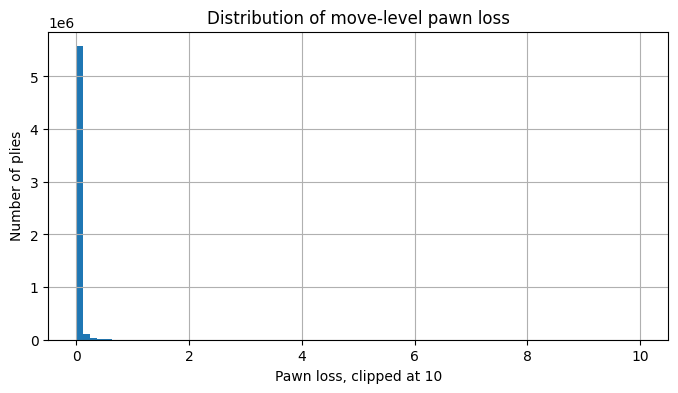

In [10]:
print("Eval summary")
display(plies_ml["eval_pawns"].describe(percentiles=[
  0.01,
  0.05,
  0.25,
  0.5,
  0.75,
  0.95,
  0.99,
]))

print("Pawn-loss summary")
display(plies_ml["pawn_loss"].describe(percentiles=[
  0.5,
  0.75,
  0.9,
  0.95,
  0.99,
  0.999,
]))

print("Move-level mistake/blunder fractions")
display(plies_ml[["is_mistake", "is_blunder"]].mean().to_frame("fraction"))

fig, ax = plt.subplots(figsize=(8, 4))
plies_ml["pawn_loss"].clip(0, 10).hist(bins=80, ax=ax)
ax.set_xlabel("Pawn loss, clipped at 10")
ax.set_ylabel("Number of plies")
ax.set_title("Distribution of move-level pawn loss")
plt.show()


## 7. Future-blunder target


In [11]:
def add_future_blunder_target_fast(df, horizon_own_moves):
  df = df.copy()
  df = df.sort_values([game_id_col, "mover", ply_col])

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)["is_blunder"]

  future_count = pd.Series(0, index=df.index, dtype=float)

  for step in range(1, horizon_own_moves + 1):
    future_count += group.shift(-step).fillna(0)

  df["future_blunder_count"] = future_count
  df["will_blunder_soon"] = (
    df["future_blunder_count"].gt(0).astype(int)
  )

  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return df


plies_ml = add_future_blunder_target_fast(
  plies_ml,
  HORIZON_OWN_MOVES,
)

print("Future-blunder target counts")
display(plies_ml["will_blunder_soon"].value_counts(dropna=False))
display(plies_ml["will_blunder_soon"].value_counts(
  normalize=True,
  dropna=False,
))

game_target = (
  pd.DataFrame({
    "game_id": plies_ml[game_id_col],
    "target": plies_ml["will_blunder_soon"],
  })
  .groupby("game_id")["target"]
  .max()
)

print("Games with at least one positive target")
display(game_target.value_counts(dropna=False))
display(game_target.value_counts(normalize=True, dropna=False))


Future-blunder target counts


will_blunder_soon
0    6384552
1      26019
Name: count, dtype: int64

will_blunder_soon
0    0.995941
1    0.004059
Name: proportion, dtype: float64

Games with at least one positive target


target
0    95195
1     4805
Name: count, dtype: int64

target
0    0.95195
1    0.04805
Name: proportion, dtype: float64

## 8. Legal pre-blunder features


In [12]:
def add_rolling_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  group = df.groupby(game_id_col, sort=False)

  df["abs_eval_pawns"] = df["eval_pawns"].abs()
  df["eval_sign"] = np.sign(df["eval_pawns"]).astype(float)

  df["eval_prev_1"] = group["eval_pawns"].shift(1)
  df["eval_prev_2"] = group["eval_pawns"].shift(2)
  df["eval_prev_4"] = group["eval_pawns"].shift(4)

  df["eval_change_prev_1"] = df["eval_pawns"] - df["eval_prev_1"]
  df["eval_change_prev_2"] = df["eval_pawns"] - df["eval_prev_2"]
  df["eval_change_prev_4"] = df["eval_pawns"] - df["eval_prev_4"]

  df["abs_eval_change_prev_1"] = df["eval_change_prev_1"].abs()
  df["abs_eval_change_prev_2"] = df["eval_change_prev_2"].abs()
  df["abs_eval_change_prev_4"] = df["eval_change_prev_4"].abs()

  df["game_ply_fraction"] = group.cumcount()
  max_ply = group["game_ply_fraction"].transform("max").replace(0, np.nan)
  df["game_ply_fraction"] = df["game_ply_fraction"] / max_ply

  df["phase"] = pd.cut(
    df["fullmove_number"].astype(float),
    bins=[0, 10, 25, 10_000],
    labels=["opening", "middlegame", "endgame"],
    include_lowest=True,
  )

  return df


def add_player_history_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)

  prev_blunder = group["is_blunder"].shift(1).fillna(0)
  prev_mistake = group["is_mistake"].shift(1).fillna(0)
  prev_pawn_loss = group["pawn_loss"].shift(1)

  hist_keys = [df[game_id_col], df["mover"]]

  df["prev_own_blunders"] = (
    prev_blunder
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_mistakes"] = (
    prev_mistake
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_pawn_loss"] = prev_pawn_loss

  for window in [3, 5, 10]:
    shifted_loss = group["pawn_loss"].shift(1)

    rolled = (
      shifted_loss
      .groupby(hist_keys, sort=False)
      .rolling(window, min_periods=1)
      .mean()
    )

    df[f"prev_own_pawn_loss_mean_{window}"] = (
      rolled.reset_index(level=[0, 1], drop=True)
    )

  return df


plies_ml = add_rolling_features(plies_ml)
plies_ml = add_player_history_features(plies_ml)


In [13]:
candidate_features = [
  "eval_pawns",
  "abs_eval_pawns",
  "eval_sign",
  "fullmove_number",
  "game_ply_fraction",
  "eval_prev_1",
  "eval_prev_2",
  "eval_prev_4",
  "eval_change_prev_1",
  "eval_change_prev_2",
  "eval_change_prev_4",
  "abs_eval_change_prev_1",
  "abs_eval_change_prev_2",
  "abs_eval_change_prev_4",
  "prev_own_blunders",
  "prev_own_mistakes",
  "prev_own_pawn_loss",
  "prev_own_pawn_loss_mean_3",
  "prev_own_pawn_loss_mean_5",
  "prev_own_pawn_loss_mean_10",
  "mover",
  "phase",
]

feature_cols = [c for c in candidate_features if c in plies_ml.columns]

print("Feature columns:")
for col in feature_cols:
  print(" ", col)


Feature columns:
  eval_pawns
  abs_eval_pawns
  eval_sign
  fullmove_number
  game_ply_fraction
  eval_prev_1
  eval_prev_2
  eval_prev_4
  eval_change_prev_1
  eval_change_prev_2
  eval_change_prev_4
  abs_eval_change_prev_1
  abs_eval_change_prev_2
  abs_eval_change_prev_4
  prev_own_blunders
  prev_own_mistakes
  prev_own_pawn_loss
  prev_own_pawn_loss_mean_3
  prev_own_pawn_loss_mean_5
  prev_own_pawn_loss_mean_10
  mover
  phase


In [14]:
model_df = plies_ml.dropna(subset=["will_blunder_soon"]).copy()

# Remove last plies where the full future horizon cannot exist.
group = model_df.groupby(game_id_col, sort=False)
max_ply = group[ply_col].transform("max")
min_future_gap = 2 * HORIZON_OWN_MOVES
model_df = model_df[model_df[ply_col] <= max_ply - min_future_gap].copy()

X = model_df[feature_cols]
y = model_df["will_blunder_soon"].astype(int)
groups = model_df[game_id_col]

print("Model rows:", len(model_df))
print("Unique games:", groups.nunique())
print("Positive target rate:", y.mean())

print("Target counts")
display(y.value_counts(dropna=False))
display(y.value_counts(normalize=True, dropna=False))

display(X.head())


Model rows: 5410769
Unique games: 99889
Positive target rate: 0.004220656989792024
Target counts


will_blunder_soon
0    5387932
1      22837
Name: count, dtype: int64

will_blunder_soon
0    0.995779
1    0.004221
Name: proportion, dtype: float64

,eval_pawns,abs_eval_pawns,eval_sign,fullmove_number,game_ply_fraction,eval_prev_1,eval_prev_2,eval_prev_4,eval_change_prev_1,eval_change_prev_2,eval_change_prev_4,abs_eval_change_prev_1,abs_eval_change_prev_2,abs_eval_change_prev_4,prev_own_blunders,prev_own_mistakes,prev_own_pawn_loss,prev_own_pawn_loss_mean_3,prev_own_pawn_loss_mean_5,prev_own_pawn_loss_mean_10,mover,phase
0,0.14,0.14,1.0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,white,opening
1,0.26,0.26,1.0,1,0.030303,0.14,NaN,NaN,0.12,NaN,NaN,0.12,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,black,opening
2,0.23,0.23,1.0,2,0.060606,0.26,0.14,NaN,-0.03,0.09,NaN,0.03,0.09,NaN,0.0,0.0,0.0,0.0,0.0,0.0,white,opening
3,0.36,0.36,1.0,2,0.090909,0.23,0.26,NaN,0.13,0.10,NaN,0.13,0.10,NaN,0.0,0.0,0.0,0.0,0.0,0.0,black,opening
4,0.25,0.25,1.0,3,0.121212,0.36,0.23,0.14,-0.11,0.02,0.11,0.11,0.02,0.11,0.0,0.0,0.0,0.0,0.0,0.0,white,opening


## 9. Stratified split by game


In [15]:
def stratified_game_train_valid_test_split(
  X,
  y,
  groups,
  seed=RANDOM_STATE,
):
  game_df = (
    pd.DataFrame({
      "game_id": groups,
      "target": y,
    })
    .groupby("game_id", as_index=False)["target"]
    .max()
  )

  if game_df["target"].nunique() < 2:
    raise ValueError(
      "Only one game-level target class exists. Lower "
      "BLUNDER_PAWN_LOSS or increase N_GAMES_SAMPLE."
    )

  train_games, temp_games = train_test_split(
    game_df,
    train_size=0.70,
    random_state=seed,
    stratify=game_df["target"],
  )

  valid_games, test_games = train_test_split(
    temp_games,
    train_size=0.50,
    random_state=seed,
    stratify=temp_games["target"],
  )

  train_ids = set(train_games["game_id"])
  valid_ids = set(valid_games["game_id"])
  test_ids = set(test_games["game_id"])

  train_mask = groups.isin(train_ids)
  valid_mask = groups.isin(valid_ids)
  test_mask = groups.isin(test_ids)

  X_train = X.loc[train_mask]
  y_train = y.loc[train_mask]
  g_train = groups.loc[train_mask]

  X_valid = X.loc[valid_mask]
  y_valid = y.loc[valid_mask]
  g_valid = groups.loc[valid_mask]

  X_test = X.loc[test_mask]
  y_test = y.loc[test_mask]
  g_test = groups.loc[test_mask]

  for split_name, split_y in [
    ("train", y_train),
    ("valid", y_valid),
    ("test", y_test),
  ]:
    if split_y.nunique() < 2:
      raise ValueError(
        f"{split_name} has only one row-level target class. "
        "Increase N_GAMES_SAMPLE or lower BLUNDER_PAWN_LOSS."
      )

  return (
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    g_train,
    g_valid,
    g_test,
  )


split = stratified_game_train_valid_test_split(X, y, groups)

(
  X_train,
  X_valid,
  X_test,
  y_train,
  y_valid,
  y_test,
  g_train,
  g_valid,
  g_test,
) = split

print("train:", X_train.shape, y_train.mean(), g_train.nunique())
print("valid:", X_valid.shape, y_valid.mean(), g_valid.nunique())
print("test: ", X_test.shape, y_test.mean(), g_test.nunique())

print("\nTrain target counts")
display(y_train.value_counts())

print("\nValid target counts")
display(y_valid.value_counts())

print("\nTest target counts")
display(y_test.value_counts())


train: (3788377, 22) 0.004228987769696628 69922
valid: (813312, 22) 0.004141092225369846 14983
test:  (809080, 22) 0.004261630493894299 14984

Train target counts


will_blunder_soon
0    3772356
1      16021
Name: count, dtype: int64


Valid target counts


will_blunder_soon
0    809944
1      3368
Name: count, dtype: int64


Test target counts


will_blunder_soon
0    805632
1      3448
Name: count, dtype: int64

## 10. Shared preprocessing


In [16]:
numeric_cols = [
  c for c in feature_cols
  if pd.api.types.is_numeric_dtype(X_train[c])
]

categorical_cols = [
  c for c in feature_cols
  if c not in numeric_cols
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_preprocess_scaled = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler()),
])

numeric_preprocess_unscaled = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_tree = ColumnTransformer([
  ("num", numeric_preprocess_unscaled, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_nn = ColumnTransformer([
  ("num", numeric_preprocess_scaled, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_linear = ColumnTransformer([
  ("num", numeric_preprocess_scaled, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])


Numeric columns: ['eval_pawns', 'abs_eval_pawns', 'eval_sign', 'fullmove_number', 'game_ply_fraction', 'eval_prev_1', 'eval_prev_2', 'eval_prev_4', 'eval_change_prev_1', 'eval_change_prev_2', 'eval_change_prev_4', 'abs_eval_change_prev_1', 'abs_eval_change_prev_2', 'abs_eval_change_prev_4', 'prev_own_blunders', 'prev_own_mistakes', 'prev_own_pawn_loss', 'prev_own_pawn_loss_mean_3', 'prev_own_pawn_loss_mean_5', 'prev_own_pawn_loss_mean_10']
Categorical columns: ['mover', 'phase']


## 11. Utility functions


In [17]:
def get_score(model, X_eval):
  if hasattr(model, "predict_proba"):
    proba = model.predict_proba(X_eval)

    if proba.shape[1] == 1:
      only_class = model.classes_[0]
      if only_class == 1:
        return np.ones(len(X_eval))
      return np.zeros(len(X_eval))

    positive_index = list(model.classes_).index(1)
    return proba[:, positive_index]

  if hasattr(model, "decision_function"):
    score = model.decision_function(X_eval)
    return 1 / (1 + np.exp(-score))

  return model.predict(X_eval)


def find_best_threshold(y_true, score, metric="f1"):
  rows = []

  for threshold in np.linspace(0.01, 0.99, 99):
    pred = (score >= threshold).astype(int)

    rows.append({
      "threshold": threshold,
      "f1": f1_score(y_true, pred),
      "balanced_acc": balanced_accuracy_score(y_true, pred),
      "pred_positive_rate": pred.mean(),
    })

  threshold_df = pd.DataFrame(rows)

  if metric not in threshold_df.columns:
    raise ValueError(f"Unknown threshold metric: {metric}")

  best = threshold_df.sort_values(metric, ascending=False).iloc[0]

  return float(best["threshold"]), threshold_df


def evaluate_scores(name, y_true, score, threshold=0.5):
  pred = (score >= threshold).astype(int)

  return {
    "model": name,
    "threshold": threshold,
    "roc_auc": roc_auc_score(y_true, score),
    "avg_precision": average_precision_score(y_true, score),
    "balanced_acc": balanced_accuracy_score(y_true, pred),
    "f1": f1_score(y_true, pred),
    "pred_positive_rate": pred.mean(),
    "true_positive_rate": y_true.mean(),
  }


def fit_and_score_sklearn_model(name, model):
  start = time.time()
  model.fit(X_train, y_train)
  fit_seconds = time.time() - start

  valid_score = get_score(model, X_valid)
  threshold, threshold_df = find_best_threshold(y_valid, valid_score)

  valid_metrics_05 = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=0.5,
  )

  valid_metrics_opt = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=threshold,
  )

  test_score = get_score(model, X_test)

  test_metrics_opt = evaluate_scores(
    name,
    y_test,
    test_score,
    threshold=threshold,
  )

  for row in [valid_metrics_05, valid_metrics_opt, test_metrics_opt]:
    row["fit_seconds"] = fit_seconds

  artifact = {
    "name": name,
    "model": model,
    "threshold": threshold,
    "threshold_df": threshold_df,
    "valid_score": valid_score,
    "test_score": test_score,
    "valid_metrics_05": valid_metrics_05,
    "valid_metrics_opt": valid_metrics_opt,
    "test_metrics_opt": test_metrics_opt,
  }

  return artifact


def record_artifact(artifact):
  artifacts[artifact["name"]] = artifact

  valid_rows.append({
    **artifact["valid_metrics_05"],
    "split": "valid",
    "setting": "threshold_0.5",
  })

  valid_rows.append({
    **artifact["valid_metrics_opt"],
    "split": "valid",
    "setting": "threshold_optimized",
  })

  test_rows.append({
    **artifact["test_metrics_opt"],
    "split": "test",
    "setting": "threshold_optimized",
  })


def plot_threshold_scan(artifact):
  threshold_df = artifact["threshold_df"]

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
  ax.plot(
    threshold_df["threshold"],
    threshold_df["balanced_acc"],
    label="Balanced accuracy",
  )
  ax.axvline(
    artifact["threshold"],
    linestyle="--",
    label="Selected threshold",
  )
  ax.set_xlabel("Threshold")
  ax.set_ylabel("Validation score")
  ax.set_title(f"Threshold scan: {artifact['name']}")
  ax.legend()
  plt.show()


def plot_confusion_matrix_for_artifact(artifact):
  score = artifact["test_score"]
  pred = (score >= artifact["threshold"]).astype(int)

  disp = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
  disp.plot()
  plt.title(f"Test confusion matrix: {artifact['name']}")
  plt.show()


artifacts = {}
valid_rows = []
test_rows = []


## 12. Baseline sanity models


In [18]:
baseline_models = {
  "dummy_prior": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DummyClassifier(strategy="prior")),
  ]),
  "logreg_baseline": Pipeline([
    ("preprocess", preprocess_linear),
    ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      random_state=RANDOM_STATE,
    )),
  ]),
}

for name, model in baseline_models.items():
  print(f"Training {name}...")
  artifact = fit_and_score_sklearn_model(name, model)
  record_artifact(artifact)

summary_valid = pd.DataFrame(valid_rows)
summary_test = pd.DataFrame(test_rows)

display(summary_valid.sort_values("avg_precision", ascending=False))
display(summary_test.sort_values("avg_precision", ascending=False))


Training dummy_prior...
Training logreg_baseline...


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,split,setting
2,logreg_baseline,0.50,0.87775,0.027582,0.800217,0.027814,0.247659,0.004141,12.643878,valid,threshold_0.5
3,logreg_baseline,0.89,0.87775,0.027582,0.590609,0.066742,0.020839,0.004141,12.643878,valid,threshold_optimized
0,dummy_prior,0.50,0.50000,0.004141,0.500000,0.000000,0.000000,0.004141,12.888794,valid,threshold_0.5
1,dummy_prior,0.01,0.50000,0.004141,0.500000,0.000000,0.000000,0.004141,12.888794,valid,threshold_optimized


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,split,setting
1,logreg_baseline,0.89,0.877514,0.028945,0.591471,0.071061,0.019984,0.004262,12.643878,test,threshold_optimized
0,dummy_prior,0.01,0.500000,0.004262,0.500000,0.000000,0.000000,0.004262,12.888794,test,threshold_optimized


## 13. XGBoost baseline and optimization


In [19]:
if HAS_XGBOOST:
  from xgboost import XGBClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  xgb_baseline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      n_estimators=350,
      max_depth=4,
      learning_rate=0.05,
      subsample=0.8,
      colsample_bytree=0.8,
      min_child_weight=5,
      reg_lambda=2.0,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      tree_method="hist",
    )),
  ])

  print("Training xgboost_baseline...")
  artifact = fit_and_score_sklearn_model("xgboost_baseline", xgb_baseline)
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

else:
  print("Skipping XGBoost because xgboost is not installed.")


Training xgboost_baseline...


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,xgboost_baseline,0.50,0.928570,0.056158,0.855235,0.043956,0.159159,0.004141,21.529253
1,xgboost_baseline,0.94,0.928570,0.056158,0.615225,0.116648,0.013082,0.004141,21.529253
2,xgboost_baseline,0.94,0.925671,0.060977,0.613402,0.120785,0.012561,0.004262,21.529253


In [20]:
if HAS_XGBOOST and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna
  from xgboost import XGBClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  def objective_xgb(trial):
    params = {
      "n_estimators": trial.suggest_int("n_estimators", 200, 700),
      "max_depth": trial.suggest_int("max_depth", 2, 8),
      "learning_rate": trial.suggest_float(
        "learning_rate",
        0.01,
        0.12,
        log=True,
      ),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float(
        "colsample_bytree",
        0.6,
        1.0,
      ),
      "min_child_weight": trial.suggest_float(
        "min_child_weight",
        1.0,
        20.0,
        log=True,
      ),
      "reg_lambda": trial.suggest_float(
        "reg_lambda",
        0.1,
        20.0,
        log=True,
      ),
      "reg_alpha": trial.suggest_float(
        "reg_alpha",
        1e-4,
        5.0,
        log=True,
      ),
    }

    model = Pipeline([
      ("preprocess", preprocess_tree),
      ("model", XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
      )),
    ])

    model.fit(X_train, y_train)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_xgb = optuna.create_study(direction="maximize")
  study_xgb.optimize(
    objective_xgb,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best XGBoost AP:", study_xgb.best_value)
  print("Best XGBoost params")
  display(study_xgb.best_params)

  xgb_optimized = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      **study_xgb.best_params,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      tree_method="hist",
    )),
  ])

  print("Training xgboost_optimized...")
  artifact = fit_and_score_sklearn_model(
    "xgboost_optimized",
    xgb_optimized,
  )
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_XGBOOST:
  print("Skipping XGBoost optimization.")


[I 2026-06-05 21:37:26,058] A new study created in memory with name: no-name-9633fc02-0dd4-4c98-931f-1cb5d1630da2


  0%|          | 0/12 [00:00<?, ?it/s]

[I 2026-06-05 21:37:51,753] Trial 0 finished with value: 0.05678916782461309 and parameters: {'n_estimators': 316, 'max_depth': 6, 'learning_rate': 0.030243976551435577, 'subsample': 0.7339955638423609, 'colsample_bytree': 0.9647573967268291, 'min_child_weight': 8.349979080349806, 'reg_lambda': 0.1660947434626249, 'reg_alpha': 0.0032952559501662217}. Best is trial 0 with value: 0.05678916782461309.
[I 2026-06-05 21:38:08,639] Trial 1 finished with value: 0.04824268254921229 and parameters: {'n_estimators': 206, 'max_depth': 2, 'learning_rate': 0.035062048315563546, 'subsample': 0.9376345852607151, 'colsample_bytree': 0.8484369396995184, 'min_child_weight': 4.529808251260834, 'reg_lambda': 4.200266612519009, 'reg_alpha': 3.4719544805617595}. Best is trial 0 with value: 0.05678916782461309.
[I 2026-06-05 21:38:41,143] Trial 2 finished with value: 0.0569587409948141 and parameters: {'n_estimators': 675, 'max_depth': 4, 'learning_rate': 0.03671686796112205, 'subsample': 0.7446760665787244,

{'n_estimators': 328,
 'max_depth': 8,
 'learning_rate': 0.018342087990541694,
 'subsample': 0.6311295928740865,
 'colsample_bytree': 0.6520717405510049,
 'min_child_weight': 14.141362567249704,
 'reg_lambda': 7.33841023963163,
 'reg_alpha': 0.5131586872273277}

Training xgboost_optimized...


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,xgboost_optimized,0.50,0.927691,0.057019,0.851723,0.047720,0.142104,0.004141,28.20521
1,xgboost_optimized,0.91,0.927691,0.057019,0.667292,0.117897,0.020721,0.004141,28.20521
2,xgboost_optimized,0.91,0.924601,0.059913,0.662620,0.120272,0.020114,0.004262,28.20521


## 14. LightGBM baseline and optimization


In [21]:
if HAS_LIGHTGBM:
  from lightgbm import LGBMClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  lgbm_baseline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", LGBMClassifier(
      n_estimators=500,
      num_leaves=31,
      learning_rate=0.04,
      subsample=0.8,
      colsample_bytree=0.8,
      min_child_samples=50,
      reg_lambda=2.0,
      objective="binary",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      verbose=-1,
    )),
  ])

  print("Training lightgbm_baseline...")
  artifact = fit_and_score_sklearn_model("lightgbm_baseline", lgbm_baseline)
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

else:
  print("Skipping LightGBM because lightgbm is not installed.")


Training lightgbm_baseline...


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,lightgbm_baseline,0.50,0.920807,0.050917,0.845293,0.045330,0.148676,0.004141,24.859166
1,lightgbm_baseline,0.94,0.920807,0.050917,0.624815,0.109038,0.015953,0.004141,24.859166
2,lightgbm_baseline,0.94,0.918743,0.051938,0.618491,0.110066,0.015188,0.004262,24.859166


In [22]:
if HAS_LIGHTGBM and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna
  from lightgbm import LGBMClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  def objective_lgbm(trial):
    params = {
      "n_estimators": trial.suggest_int("n_estimators", 250, 900),
      "num_leaves": trial.suggest_int("num_leaves", 15, 127),
      "learning_rate": trial.suggest_float(
        "learning_rate",
        0.01,
        0.12,
        log=True,
      ),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float(
        "colsample_bytree",
        0.6,
        1.0,
      ),
      "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
      "reg_lambda": trial.suggest_float(
        "reg_lambda",
        0.1,
        20.0,
        log=True,
      ),
      "reg_alpha": trial.suggest_float(
        "reg_alpha",
        1e-4,
        5.0,
        log=True,
      ),
    }

    model = Pipeline([
      ("preprocess", preprocess_tree),
      ("model", LGBMClassifier(
        **params,
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
      )),
    ])

    model.fit(X_train, y_train)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_lgbm = optuna.create_study(direction="maximize")
  study_lgbm.optimize(
    objective_lgbm,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best LightGBM AP:", study_lgbm.best_value)
  print("Best LightGBM params")
  display(study_lgbm.best_params)

  lgbm_optimized = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", LGBMClassifier(
      **study_lgbm.best_params,
      objective="binary",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
      verbose=-1,
    )),
  ])

  print("Training lightgbm_optimized...")
  artifact = fit_and_score_sklearn_model(
    "lightgbm_optimized",
    lgbm_optimized,
  )
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_LIGHTGBM:
  print("Skipping LightGBM optimization.")


[I 2026-06-05 21:44:28,850] A new study created in memory with name: no-name-9442605a-0e0a-460d-a180-a49b3c7f9ddc


  0%|          | 0/12 [00:00<?, ?it/s]

[I 2026-06-05 21:44:52,394] Trial 0 finished with value: 0.054172012308705914 and parameters: {'n_estimators': 355, 'num_leaves': 22, 'learning_rate': 0.023480534300493877, 'subsample': 0.9155484065505205, 'colsample_bytree': 0.9462468088377911, 'min_child_samples': 51, 'reg_lambda': 0.1828084157188765, 'reg_alpha': 0.013215031419702495}. Best is trial 0 with value: 0.054172012308705914.
[I 2026-06-05 21:45:15,382] Trial 1 finished with value: 0.05100507737572217 and parameters: {'n_estimators': 396, 'num_leaves': 19, 'learning_rate': 0.05015388684850577, 'subsample': 0.7364643324378704, 'colsample_bytree': 0.6119455024702435, 'min_child_samples': 20, 'reg_lambda': 15.205564859990135, 'reg_alpha': 1.0580504736606209}. Best is trial 0 with value: 0.054172012308705914.
[I 2026-06-05 21:45:41,077] Trial 2 finished with value: 0.05528116499625766 and parameters: {'n_estimators': 322, 'num_leaves': 50, 'learning_rate': 0.01622785615320487, 'subsample': 0.9261691843239663, 'colsample_bytree'

{'n_estimators': 526,
 'num_leaves': 124,
 'learning_rate': 0.010333496906067913,
 'subsample': 0.6036126650773669,
 'colsample_bytree': 0.8529728945130814,
 'min_child_samples': 196,
 'reg_lambda': 4.434291250099777,
 'reg_alpha': 0.09659097025210349}

Training lightgbm_optimized...


,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds
0,lightgbm_optimized,0.50,0.926117,0.057832,0.848187,0.047907,0.139943,0.004141,45.535175
1,lightgbm_optimized,0.91,0.926117,0.057832,0.663078,0.117362,0.020206,0.004141,45.535175
2,lightgbm_optimized,0.91,0.923774,0.061230,0.658787,0.119826,0.019627,0.004262,45.535175


## 15. PyTorch utilities with progress and row sampling


In [19]:
if HAS_TORCH:
  import torch
  import torch.nn as nn
  from torch.utils.data import DataLoader, TensorDataset

  torch.manual_seed(RANDOM_STATE)

  torch.set_num_threads(TORCH_NUM_THREADS)

  try:
    torch.set_num_interop_threads(1)
  except RuntimeError:
    pass

  if FORCE_TORCH_CPU:
    DEVICE = torch.device("cpu")
  elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
  elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
  else:
    DEVICE = torch.device("cpu")

  print("PyTorch device:", DEVICE)
  print("PyTorch num threads:", torch.get_num_threads())
else:
  print("Skipping PyTorch utilities because torch is not installed.")


PyTorch device: cpu
PyTorch num threads: 1


In [21]:
def sample_rows_for_nn(X, y, max_rows, seed=RANDOM_STATE):
  if max_rows is None or len(X) <= max_rows:
    return X, y

  sampled_idx, _ = train_test_split(
    X.index,
    train_size=max_rows,
    random_state=seed,
    stratify=y,
  )

  return X.loc[sampled_idx], y.loc[sampled_idx]


def fit_and_score_nn_model(name, model):
  X_train_nn, y_train_nn = sample_rows_for_nn(
    X_train,
    y_train,
    NN_TRAIN_MAX_ROWS,
    seed=RANDOM_STATE,
  )

  print("=" * 80)
  print(f"Training {name}")
  print(f"Full train rows: {len(X_train):,}")
  print(f"NN train rows:   {len(X_train_nn):,}")
  print(f"Valid rows:      {len(X_valid):,}")
  print(f"Test rows:       {len(X_test):,}")
  print(f"Target rate in NN train: {y_train_nn.mean():.4f}")
  print("=" * 80)

  start = time.time()

  print("[1/4] Fitting preprocessing + neural network...")
  model.fit(X_train_nn, y_train_nn)
  fit_seconds = time.time() - start
  print(f"Fit finished in {fit_seconds:.1f} seconds")

  print("[2/4] Predicting validation scores...")
  valid_score = get_score(model, X_valid)

  print("[3/4] Optimizing threshold on validation set...")
  threshold, threshold_df = find_best_threshold(y_valid, valid_score)

  valid_metrics_05 = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=0.5,
  )

  valid_metrics_opt = evaluate_scores(
    name,
    y_valid,
    valid_score,
    threshold=threshold,
  )

  print("[4/4] Predicting test scores...")
  test_score = get_score(model, X_test)

  test_metrics_opt = evaluate_scores(
    name,
    y_test,
    test_score,
    threshold=threshold,
  )

  for row in [valid_metrics_05, valid_metrics_opt, test_metrics_opt]:
    row["fit_seconds"] = fit_seconds
    row["nn_train_rows"] = len(X_train_nn)

  artifact = {
    "name": name,
    "model": model,
    "threshold": threshold,
    "threshold_df": threshold_df,
    "valid_score": valid_score,
    "test_score": test_score,
    "valid_metrics_05": valid_metrics_05,
    "valid_metrics_opt": valid_metrics_opt,
    "test_metrics_opt": test_metrics_opt,
  }

  print("Done.")
  return artifact


In [22]:
if HAS_TORCH:
  def to_dense_float32(x):
    if hasattr(x, "toarray"):
      x = x.toarray()
    return np.asarray(x, dtype=np.float32)


  class TorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, depth=3, dropout=0.15):
      super().__init__()
  
      layers = []
      in_dim = input_dim
  
      for _ in range(depth):
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        in_dim = hidden_dim
  
      layers.append(nn.Linear(in_dim, 1))
      self.net = nn.Sequential(*layers)
  
    def forward(self, x):
      return self.net(x).squeeze(-1)


  class NumericTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
      super().__init__()
      self.weight = nn.Parameter(torch.randn(n_features, d_token) * 0.02)
      self.bias = nn.Parameter(torch.zeros(n_features, d_token))

    def forward(self, x):
      return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


  class FTTransformerLite(nn.Module):
    def __init__(
      self,
      n_features,
      d_token=24,
      n_heads=4,
      n_layers=2,
      dropout=0.15,
    ):
      super().__init__()

      self.tokenizer = NumericTokenizer(n_features, d_token)
      self.cls = nn.Parameter(torch.zeros(1, 1, d_token))

      encoder_layer = nn.TransformerEncoderLayer(
        d_model=d_token,
        nhead=n_heads,
        dim_feedforward=4 * d_token,
        dropout=dropout,
        batch_first=True,
        activation="gelu",
      )

      self.encoder = nn.TransformerEncoder(
        encoder_layer,
        num_layers=n_layers,
      )

      self.head = nn.Sequential(
        nn.LayerNorm(d_token),
        nn.Linear(d_token, 1),
      )

    def forward(self, x):
      tokens = self.tokenizer(x)
      cls = self.cls.expand(x.shape[0], -1, -1)
      tokens = torch.cat([cls, tokens], dim=1)
      encoded = self.encoder(tokens)
      cls_out = encoded[:, 0, :]
      return self.head(cls_out).squeeze(-1)


  class TorchTabularClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
      self,
      model_type="mlp",
      hidden_dim=128,
      depth=3,
      dropout=0.15,
      lr=1e-3,
      weight_decay=1e-4,
      batch_size=8192,
      max_epochs=8,
      patience=3,
      d_token=24,
      n_heads=4,
      n_layers=2,
      random_state=RANDOM_STATE,
      verbose=False,
    ):
      self.model_type = model_type
      self.hidden_dim = hidden_dim
      self.depth = depth
      self.dropout = dropout
      self.lr = lr
      self.weight_decay = weight_decay
      self.batch_size = batch_size
      self.max_epochs = max_epochs
      self.patience = patience
      self.d_token = d_token
      self.n_heads = n_heads
      self.n_layers = n_layers
      self.random_state = random_state
      self.verbose = verbose

    def _make_model(self, input_dim):
      if self.model_type == "mlp":
        return TorchMLP(
          input_dim=input_dim,
          hidden_dim=self.hidden_dim,
          depth=self.depth,
          dropout=self.dropout,
        )

      if self.model_type == "ft_transformer":
        return FTTransformerLite(
          n_features=input_dim,
          d_token=self.d_token,
          n_heads=self.n_heads,
          n_layers=self.n_layers,
          dropout=self.dropout,
        )

      raise ValueError(f"Unknown model_type: {self.model_type}")

    def fit(self, X, y):
      torch.manual_seed(self.random_state)

      print("  [NN] converting preprocessed matrix to dense float32...")
      X = to_dense_float32(X)
      y = np.asarray(y, dtype=np.float32)

      print(f"  [NN] dense matrix shape: {X.shape}")
      print(f"  [NN] dense matrix size: {X.nbytes / 1e9:.2f} GB")

      X_train_arr, X_val_arr, y_train_arr, y_val_arr = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=self.random_state,
        stratify=y,
      )

      if len(X_val_arr) > NN_VALID_INTERNAL_MAX_ROWS:
        val_idx, _ = train_test_split(
          np.arange(len(X_val_arr)),
          train_size=NN_VALID_INTERNAL_MAX_ROWS,
          random_state=self.random_state,
          stratify=y_val_arr,
        )

        X_val_arr = X_val_arr[val_idx]
        y_val_arr = y_val_arr[val_idx]

      print(f"  [NN] internal train rows: {len(X_train_arr):,}")
      print(f"  [NN] internal valid rows: {len(X_val_arr):,}")

      self.classes_ = np.array([0, 1])
      self.input_dim_ = X.shape[1]
      self.model_ = self._make_model(self.input_dim_).to(DEVICE)

      pos = max(float((y_train_arr == 1).sum()), 1.0)
      neg = max(float((y_train_arr == 0).sum()), 1.0)
      pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(DEVICE)

      loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
      optimizer = torch.optim.AdamW(
        self.model_.parameters(),
        lr=self.lr,
        weight_decay=self.weight_decay,
      )

      train_ds = TensorDataset(
        torch.tensor(X_train_arr),
        torch.tensor(y_train_arr),
      )
      val_x = torch.tensor(X_val_arr).to(DEVICE)

      train_loader = DataLoader(
        train_ds,
        batch_size=self.batch_size,
        shuffle=True,
        drop_last=False,
      )

      best_ap = -np.inf
      best_state = None
      bad_epochs = 0
      self.history_ = []

      n_batches = len(train_loader)

      for epoch in range(self.max_epochs):
        epoch_start = time.time()
        self.model_.train()
        train_loss_sum = 0.0
        n_seen = 0

        for batch_i, (xb, yb) in enumerate(train_loader):
          xb = xb.to(DEVICE)
          yb = yb.to(DEVICE)

          optimizer.zero_grad()
          logits = self.model_(xb)
          loss = loss_fn(logits, yb)
          loss.backward()
          optimizer.step()

          train_loss_sum += float(loss.item()) * len(xb)
          n_seen += len(xb)

          should_print = (
            batch_i == 0
            or (batch_i + 1) % NN_PROGRESS_EVERY_N_BATCHES == 0
            or (batch_i + 1) == n_batches
          )

          if self.verbose and should_print:
            print(
              f"  epoch {epoch + 1:03d}/{self.max_epochs:03d} "
              f"batch {batch_i + 1:04d}/{n_batches:04d} "
              f"loss={float(loss.item()):.4f}",
              flush=True,
            )

        self.model_.eval()
        with torch.no_grad():
          val_logits = self.model_(val_x)
          val_prob = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val_arr, val_prob)
        train_loss = train_loss_sum / max(n_seen, 1)
        epoch_seconds = time.time() - epoch_start

        self.history_.append({
          "epoch": epoch,
          "train_loss": train_loss,
          "val_avg_precision": val_ap,
          "epoch_seconds": epoch_seconds,
        })

        if self.verbose:
          print(
            f"  epoch={epoch:03d} "
            f"train_loss={train_loss:.4f} "
            f"val_ap={val_ap:.4f} "
            f"time={epoch_seconds:.1f}s",
            flush=True,
          )

        if val_ap > best_ap:
          best_ap = val_ap
          best_state = {
            k: v.detach().cpu().clone()
            for k, v in self.model_.state_dict().items()
          }
          bad_epochs = 0
        else:
          bad_epochs += 1

        if bad_epochs >= self.patience:
          print("  [NN] early stopping triggered.")
          break

      if best_state is not None:
        self.model_.load_state_dict(best_state)

      self.best_val_ap_ = best_ap
      return self

    def predict_proba(self, X):
      X = to_dense_float32(X)
      self.model_.eval()

      probs = []
      n = len(X)

      with torch.no_grad():
        for start in range(0, n, self.batch_size):
          stop = min(start + self.batch_size, n)
          xb = torch.tensor(X[start:stop]).to(DEVICE)
          logits = self.model_(xb)
          prob = torch.sigmoid(logits).cpu().numpy()
          probs.append(prob)

          if self.verbose and start == 0:
            print(f"  [NN] predicting {n:,} rows...")

      p1 = np.concatenate(probs)
      p0 = 1 - p1

      return np.vstack([p0, p1]).T

    def predict(self, X):
      return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


## 16. PyTorch MLP baseline and optimization


Training pytorch_mlp_baseline
Full train rows: 3,788,377
NN train rows:   300,000
Valid rows:      813,312
Test rows:       809,080
Target rate in NN train: 0.0042
[1/4] Fitting preprocessing + neural network...
  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (300000, 25)
  [NN] dense matrix size: 0.03 GB
  [NN] internal train rows: 255,000
  [NN] internal valid rows: 45,000
  epoch 001/008 batch 0001/0032 loss=1.2328
  epoch 001/008 batch 0025/0032 loss=0.9183
  epoch 001/008 batch 0032/0032 loss=0.6636
  epoch=000 train_loss=1.1302 val_ap=0.0431 time=0.9s
  epoch 002/008 batch 0001/0032 loss=0.9793
  epoch 002/008 batch 0025/0032 loss=0.8454
  epoch 002/008 batch 0032/0032 loss=0.5354
  epoch=001 train_loss=0.8100 val_ap=0.0507 time=0.9s
  epoch 003/008 batch 0001/0032 loss=0.9842
  epoch 003/008 batch 0025/0032 loss=0.8505
  epoch 003/008 batch 0032/0032 loss=1.0289
  epoch=002 train_loss=0.7632 val_ap=0.0457 time=1.0s
  epoch 004/008 batch 0001/

,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,nn_train_rows
0,pytorch_mlp_baseline,0.5,0.918415,0.045623,0.841012,0.035206,0.203520,0.004141,8.288781,300000
1,pytorch_mlp_baseline,0.9,0.918415,0.045623,0.649617,0.103263,0.021483,0.004141,8.288781,300000
2,pytorch_mlp_baseline,0.9,0.915812,0.044149,0.639427,0.099513,0.021349,0.004262,8.288781,300000


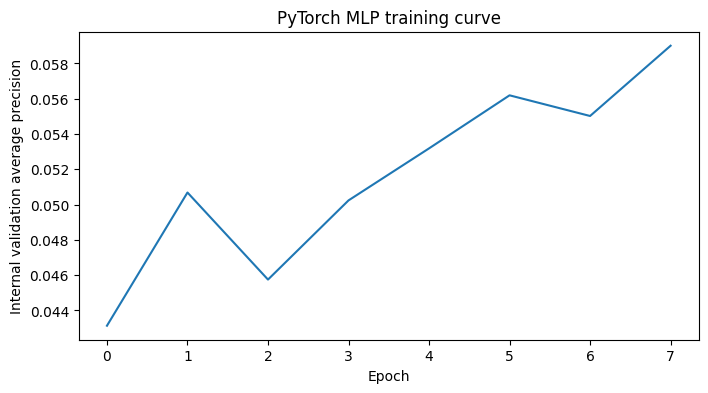

In [23]:
if HAS_TORCH:
  mlp_baseline = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="mlp",
      hidden_dim=128,
      depth=3,
      dropout=0.15,
      lr=NN_LEARNING_RATE,
      weight_decay=1e-4,
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_nn_model(
    "pytorch_mlp_baseline",
    mlp_baseline,
  )
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

  hist = artifact["model"].named_steps["model"].history_
  hist_df = pd.DataFrame(hist)

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(hist_df["epoch"], hist_df["val_avg_precision"])
  ax.set_xlabel("Epoch")
  ax.set_ylabel("Internal validation average precision")
  ax.set_title("PyTorch MLP training curve")
  plt.show()

else:
  print("Skipping PyTorch MLP because torch is not installed.")


In [24]:
if HAS_TORCH and HAS_OPTUNA and RUN_HYPERPARAM_OPT:
  import optuna

  def objective_mlp(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    depth = trial.suggest_int("depth", 2, 4)
    dropout = trial.suggest_float("dropout", 0.05, 0.35)
    lr = trial.suggest_float("lr", 3e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float(
      "weight_decay",
      1e-6,
      1e-2,
      log=True,
    )

    model = Pipeline([
      ("preprocess", preprocess_nn),
      ("model", TorchTabularClassifier(
        model_type="mlp",
        hidden_dim=hidden_dim,
        depth=depth,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        batch_size=NN_BATCH_SIZE,
        max_epochs=max(4, NN_MAX_EPOCHS // 2),
        patience=2,
        random_state=RANDOM_STATE,
        verbose=False,
      )),
    ])

    X_train_nn, y_train_nn = sample_rows_for_nn(
      X_train,
      y_train,
      min(NN_TRAIN_MAX_ROWS, 150_000),
      seed=RANDOM_STATE,
    )

    model.fit(X_train_nn, y_train_nn)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_mlp = optuna.create_study(direction="maximize")
  study_mlp.optimize(
    objective_mlp,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best MLP AP:", study_mlp.best_value)
  print("Best MLP params")
  display(study_mlp.best_params)

  p = study_mlp.best_params

  mlp_optimized = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="mlp",
      hidden_dim=p["hidden_dim"],
      depth=p["depth"],
      dropout=p["dropout"],
      lr=p["lr"],
      weight_decay=p["weight_decay"],
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_nn_model(
    "pytorch_mlp_optimized",
    mlp_optimized,
  )
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_TORCH:
  print("Skipping MLP optimization.")


[I 2026-06-05 22:16:04,136] A new study created in memory with name: no-name-54b52647-0b1a-4ae0-b98f-6ca11ab1caeb


  0%|          | 0/12 [00:00<?, ?it/s]

  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (150000, 25)
  [NN] dense matrix size: 0.01 GB
  [NN] internal train rows: 127,500
  [NN] internal valid rows: 22,500
  [NN] early stopping triggered.
[I 2026-06-05 22:16:07,812] Trial 0 finished with value: 0.03883543694897698 and parameters: {'hidden_dim': 256, 'depth': 3, 'dropout': 0.10538770806933248, 'lr': 0.0019314859891460306, 'weight_decay': 3.246422968885552e-05}. Best is trial 0 with value: 0.03883543694897698.
  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (150000, 25)
  [NN] dense matrix size: 0.01 GB
  [NN] internal train rows: 127,500
  [NN] internal valid rows: 22,500
[I 2026-06-05 22:16:10,487] Trial 1 finished with value: 0.03570455267111125 and parameters: {'hidden_dim': 64, 'depth': 2, 'dropout': 0.05900864182283008, 'lr': 0.0010831369672857085, 'weight_decay': 0.0012796042236131338}. Best is trial 0 with value: 0.03883543694897698.
  [NN] conve

{'hidden_dim': 256,
 'depth': 3,
 'dropout': 0.10634813190375529,
 'lr': 0.002711130062692573,
 'weight_decay': 0.003313511241967073}

Training pytorch_mlp_optimized
Full train rows: 3,788,377
NN train rows:   300,000
Valid rows:      813,312
Test rows:       809,080
Target rate in NN train: 0.0042
[1/4] Fitting preprocessing + neural network...
  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (300000, 25)
  [NN] dense matrix size: 0.03 GB
  [NN] internal train rows: 255,000
  [NN] internal valid rows: 45,000
  epoch 001/008 batch 0001/0032 loss=1.4403
  epoch 001/008 batch 0025/0032 loss=0.7834
  epoch 001/008 batch 0032/0032 loss=0.8321
  epoch=000 train_loss=0.8928 val_ap=0.0389 time=1.3s
  epoch 002/008 batch 0001/0032 loss=0.6698
  epoch 002/008 batch 0025/0032 loss=0.5896
  epoch 002/008 batch 0032/0032 loss=1.7295
  epoch=001 train_loss=0.7371 val_ap=0.0524 time=1.3s
  epoch 003/008 batch 0001/0032 loss=0.5870
  epoch 003/008 batch 0025/0032 loss=0.6020
  epoch 003/008 batch 0032/0032 loss=0.7223
  epoch=002 train_loss=0.7080 val_ap=0.0555 time=1.3s
  epoch 004/008 batch 0001

,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,nn_train_rows
0,pytorch_mlp_optimized,0.50,0.918868,0.049231,0.836734,0.048604,0.132766,0.004141,10.757824,300000
1,pytorch_mlp_optimized,0.94,0.918868,0.049231,0.608745,0.109624,0.013221,0.004141,10.757824,300000
2,pytorch_mlp_optimized,0.94,0.914896,0.048304,0.607582,0.113167,0.012842,0.004262,10.757824,300000


## 17. Advanced FT-Transformer-style baseline and optimization

This is the high-tech experiment. It is slower than the MLP. If you want the
fastest version of the notebook, set:

```python
RUN_FT_TRANSFORMER = False
```


FT-Transformer baseline
Training rows capped at: 50,000
Architecture:
  d_token=16
  n_heads=2
  n_layers=1
  max_epochs=3
  batch_size=2048
Training ft_transformer_baseline
Full train rows: 3,788,377
NN train rows:   50,000
Valid rows:      813,312
Test rows:       809,080
Target rate in NN train: 0.0042
[1/4] Fitting preprocessing + neural network...
  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (50000, 25)
  [NN] dense matrix size: 0.01 GB
  [NN] internal train rows: 42,500
  [NN] internal valid rows: 7,500
  epoch 001/003 batch 0001/0021 loss=1.5959
  epoch 001/003 batch 0021/0021 loss=1.5192
  epoch=000 train_loss=1.5543 val_ap=0.0171 time=1.9s
  epoch 002/003 batch 0001/0021 loss=1.6025
  epoch 002/003 batch 0021/0021 loss=1.9279
  epoch=001 train_loss=1.3018 val_ap=0.0184 time=1.7s
  epoch 003/003 batch 0001/0021 loss=1.7892
  epoch 003/003 batch 0021/0021 loss=0.7513
  epoch=002 train_loss=1.1637 val_ap=0.0191 time=1.7s
Fit finished in 5.4

,model,threshold,roc_auc,avg_precision,balanced_acc,f1,pred_positive_rate,true_positive_rate,fit_seconds,nn_train_rows
0,ft_transformer_baseline,0.50,0.869081,0.025549,0.739390,0.040354,0.117918,0.004141,5.36681,50000
1,ft_transformer_baseline,0.75,0.869081,0.025549,0.578932,0.062701,0.019155,0.004141,5.36681,50000
2,ft_transformer_baseline,0.75,0.870617,0.026809,0.582986,0.067773,0.018899,0.004262,5.36681,50000


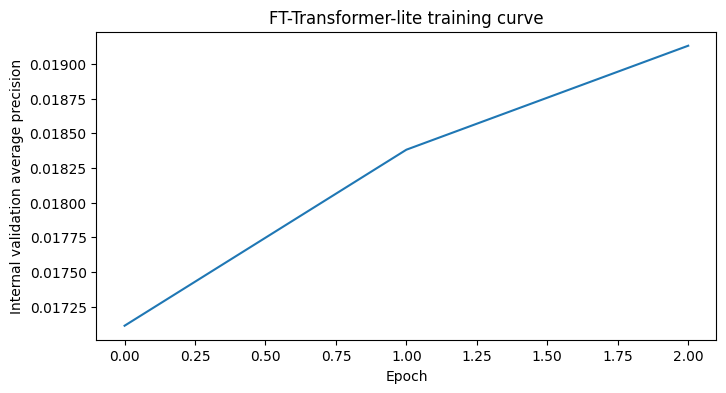

In [26]:
if HAS_TORCH and RUN_FT_TRANSFORMER:
  old_nn_train_max_rows = NN_TRAIN_MAX_ROWS

  # Keep the transformer baseline deliberately small.
  # It is an experimental comparison, not the main workhorse model.
  NN_TRAIN_MAX_ROWS = min(NN_TRAIN_MAX_ROWS, 50_000)

  print("=" * 80)
  print("FT-Transformer baseline")
  print(f"Training rows capped at: {NN_TRAIN_MAX_ROWS:,}")
  print("Architecture:")
  print("  d_token=16")
  print("  n_heads=2")
  print("  n_layers=1")
  print("  max_epochs=3")
  print("  batch_size=2048")
  print("=" * 80, flush=True)

  ft_baseline = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="ft_transformer",
      d_token=16,
      n_heads=2,
      n_layers=1,
      dropout=0.15,
      lr=NN_LEARNING_RATE,
      weight_decay=1e-4,
      batch_size=2048,
      max_epochs=3,
      patience=1,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_nn_model(
    "ft_transformer_baseline",
    ft_baseline,
  )

  NN_TRAIN_MAX_ROWS = old_nn_train_max_rows

  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

  hist = artifact["model"].named_steps["model"].history_
  hist_df = pd.DataFrame(hist)

  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(hist_df["epoch"], hist_df["val_avg_precision"])
  ax.set_xlabel("Epoch")
  ax.set_ylabel("Internal validation average precision")
  ax.set_title("FT-Transformer-lite training curve")
  plt.show()

elif HAS_TORCH:
  print("Skipping FT-Transformer because RUN_FT_TRANSFORMER = False.")
else:
  print("Skipping FT-Transformer because torch is not installed.")

In [27]:
if (
  HAS_TORCH
  and HAS_OPTUNA
  and RUN_HYPERPARAM_OPT
  and RUN_FT_TRANSFORMER
):
  import optuna

  def objective_ft(trial):
    d_token = trial.suggest_categorical("d_token", [16, 24, 32])
    n_heads_choices = [
      h for h in [2, 4, 8]
      if d_token % h == 0
    ]
    n_heads = trial.suggest_categorical("n_heads", n_heads_choices)
    n_layers = trial.suggest_int("n_layers", 1, 2)
    dropout = trial.suggest_float("dropout", 0.05, 0.30)
    lr = trial.suggest_float("lr", 2e-4, 2e-3, log=True)
    weight_decay = trial.suggest_float(
      "weight_decay",
      1e-6,
      1e-2,
      log=True,
    )

    model = Pipeline([
      ("preprocess", preprocess_nn),
      ("model", TorchTabularClassifier(
        model_type="ft_transformer",
        d_token=d_token,
        n_heads=n_heads,
        n_layers=n_layers,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        batch_size=NN_BATCH_SIZE,
        max_epochs=max(4, NN_MAX_EPOCHS // 2),
        patience=2,
        random_state=RANDOM_STATE,
        verbose=False,
      )),
    ])

    X_train_nn, y_train_nn = sample_rows_for_nn(
      X_train,
      y_train,
      min(NN_TRAIN_MAX_ROWS, 100_000),
      seed=RANDOM_STATE,
    )

    model.fit(X_train_nn, y_train_nn)
    score = get_score(model, X_valid)

    return average_precision_score(y_valid, score)


  study_ft = optuna.create_study(direction="maximize")
  study_ft.optimize(
    objective_ft,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    show_progress_bar=True,
  )

  print("Best FT-Transformer AP:", study_ft.best_value)
  print("Best FT-Transformer params")
  display(study_ft.best_params)

  p = study_ft.best_params

  ft_optimized = Pipeline([
    ("preprocess", preprocess_nn),
    ("model", TorchTabularClassifier(
      model_type="ft_transformer",
      d_token=p["d_token"],
      n_heads=p["n_heads"],
      n_layers=p["n_layers"],
      dropout=p["dropout"],
      lr=p["lr"],
      weight_decay=p["weight_decay"],
      batch_size=NN_BATCH_SIZE,
      max_epochs=NN_MAX_EPOCHS,
      patience=NN_PATIENCE,
      random_state=RANDOM_STATE,
      verbose=True,
    )),
  ])

  artifact = fit_and_score_nn_model(
    "ft_transformer_optimized",
    ft_optimized,
  )
  record_artifact(artifact)

  display(pd.DataFrame([
    artifact["valid_metrics_05"],
    artifact["valid_metrics_opt"],
    artifact["test_metrics_opt"],
  ]))

elif HAS_TORCH and RUN_FT_TRANSFORMER:
  print("Skipping FT-Transformer optimization.")


[I 2026-06-05 22:21:46,333] A new study created in memory with name: no-name-dac07197-7629-4e89-b23f-2d5b4ce9b1c7


  0%|          | 0/12 [00:00<?, ?it/s]

  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (100000, 25)
  [NN] dense matrix size: 0.01 GB
  [NN] internal train rows: 85,000
  [NN] internal valid rows: 15,000
[I 2026-06-05 22:24:09,796] Trial 0 finished with value: 0.02373121491760931 and parameters: {'d_token': 32, 'n_heads': 8, 'n_layers': 2, 'dropout': 0.20704543481102855, 'lr': 0.0007674299317993704, 'weight_decay': 0.00010347460363113997}. Best is trial 0 with value: 0.02373121491760931.
  [NN] converting preprocessed matrix to dense float32...
  [NN] dense matrix shape: (100000, 25)
  [NN] dense matrix size: 0.01 GB
  [NN] internal train rows: 85,000
  [NN] internal valid rows: 15,000
[W 2026-06-05 22:25:43,595] Trial 1 failed with parameters: {'d_token': 32, 'n_heads': 8, 'n_layers': 2, 'dropout': 0.08481527478442076, 'lr': 0.0008624348380083067, 'weight_decay': 0.009058732077351826} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/

KeyboardInterrupt: 

## 18. Summary tables and comparison plots


In [ ]:
summary_valid = pd.DataFrame(valid_rows).drop_duplicates(
  subset=["model", "setting"],
  keep="last",
)

summary_test = pd.DataFrame(test_rows).drop_duplicates(
  subset=["model", "setting"],
  keep="last",
)

display(
  summary_valid
  .sort_values(["setting", "avg_precision"], ascending=[True, False])
)

display(
  summary_test
  .sort_values("avg_precision", ascending=False)
)


In [ ]:
for metric in ["avg_precision", "roc_auc", "f1", "balanced_acc"]:
  plot_df = summary_test.sort_values(metric, ascending=True)

  fig, ax = plt.subplots(figsize=(9, 5))
  ax.barh(plot_df["model"], plot_df[metric])
  ax.set_xlabel(f"Test {metric}")
  ax.set_title(f"Model comparison: {metric}")
  plt.show()


## 19. Overlay ROC and precision-recall curves


In [ ]:
def plot_overlay_roc(artifacts_to_plot):
  fig, ax = plt.subplots(figsize=(7, 6))

  for name, artifact in artifacts_to_plot.items():
    RocCurveDisplay.from_predictions(
      y_test,
      artifact["test_score"],
      name=name,
      ax=ax,
    )

  ax.set_title("Test ROC curves")
  plt.show()


def plot_overlay_pr(artifacts_to_plot):
  fig, ax = plt.subplots(figsize=(7, 6))

  baseline_rate = y_test.mean()
  ax.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Positive rate = {baseline_rate:.3f}",
  )

  for name, artifact in artifacts_to_plot.items():
    PrecisionRecallDisplay.from_predictions(
      y_test,
      artifact["test_score"],
      name=name,
      ax=ax,
    )

  ax.set_title("Test precision-recall curves")
  plt.show()


overlay_artifacts = {
  name: artifact
  for name, artifact in artifacts.items()
  if name != "dummy_prior"
}

if len(overlay_artifacts) == 0:
  overlay_artifacts = artifacts

plot_overlay_roc(overlay_artifacts)
plot_overlay_pr(overlay_artifacts)


## 20. Confusion matrices, threshold scans, and classification reports


In [ ]:
for name, artifact in artifacts.items():
  plot_confusion_matrix_for_artifact(artifact)


In [ ]:
for name, artifact in artifacts.items():
  if name == "dummy_prior":
    continue
  plot_threshold_scan(artifact)


In [ ]:
for name, artifact in artifacts.items():
  score = artifact["test_score"]
  pred = (score >= artifact["threshold"]).astype(int)

  print("=" * 80)
  print(name)
  print(f"threshold = {artifact['threshold']:.3f}")
  print(classification_report(y_test, pred, digits=4))


## 21. Permutation importance

This is intentionally capped. If it still runs too long, reduce:

```python
PERM_IMPORTANCE_MAX_ROWS = 5_000
PERM_IMPORTANCE_REPEATS = 2
```


In [ ]:
importance_results = {}

if RUN_PERMUTATION_IMPORTANCE:
  small_n = min(PERM_IMPORTANCE_MAX_ROWS, len(X_valid))

  X_imp = X_valid.sample(small_n, random_state=RANDOM_STATE)
  y_imp = y_valid.loc[X_imp.index]

  for name, artifact in artifacts.items():
    if name == "dummy_prior":
      continue

    print(f"Permutation importance: {name}")

    perm = permutation_importance(
      artifact["model"],
      X_imp,
      y_imp,
      n_repeats=PERM_IMPORTANCE_REPEATS,
      scoring="average_precision",
      random_state=RANDOM_STATE,
      n_jobs=1,
    )

    importance_df = pd.DataFrame({
      "model": name,
      "feature": feature_cols,
      "importance_mean": perm.importances_mean,
      "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    importance_results[name] = importance_df

    display(importance_df.head(20))

else:
  print("Skipping permutation importance.")


In [ ]:
if len(importance_results) > 0:
  for name, importance_df in importance_results.items():
    plot_df = importance_df.head(20).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_df["feature"], plot_df["importance_mean"])
    ax.set_xlabel("Decrease in validation average precision")
    ax.set_title(f"Permutation importance: {name}")
    plt.show()

  all_importance = pd.concat(importance_results.values(), ignore_index=True)

  normed = all_importance.copy()

  def normalize_group(s):
    denom = s.abs().sum()
    if denom == 0:
      return s
    return s / denom

  normed["importance_norm"] = (
    normed
    .groupby("model")["importance_mean"]
    .transform(normalize_group)
  )

  feature_summary = (
    normed
    .groupby("feature", as_index=False)["importance_norm"]
    .mean()
    .sort_values("importance_norm", ascending=False)
  )

  display(feature_summary)

  plot_df = feature_summary.head(20).iloc[::-1]

  fig, ax = plt.subplots(figsize=(8, 6))
  ax.barh(plot_df["feature"], plot_df["importance_norm"])
  ax.set_xlabel("Mean normalized permutation importance")
  ax.set_title("Cross-model average feature importance")
  plt.show()


## 22. Save results


In [ ]:
OUT_DIR = ROOT / "scratch" / "model_arena_outputs_fixed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_valid.to_csv(OUT_DIR / "summary_valid.csv", index=False)
summary_test.to_csv(OUT_DIR / "summary_test.csv", index=False)

if len(importance_results) > 0:
  all_importance = pd.concat(importance_results.values(), ignore_index=True)
  all_importance.to_csv(
    OUT_DIR / "permutation_importance.csv",
    index=False,
  )

config = {
  "N_GAMES_SAMPLE": N_GAMES_SAMPLE,
  "RANDOM_GAME_SAMPLE": RANDOM_GAME_SAMPLE,
  "MISTAKE_PAWN_LOSS": MISTAKE_PAWN_LOSS,
  "BLUNDER_PAWN_LOSS": BLUNDER_PAWN_LOSS,
  "HORIZON_OWN_MOVES": HORIZON_OWN_MOVES,
  "MAX_ABS_EVAL_PAWNS": MAX_ABS_EVAL_PAWNS,
  "OPTUNA_TRIALS": OPTUNA_TRIALS,
  "NN_TRAIN_MAX_ROWS": NN_TRAIN_MAX_ROWS,
  "NN_VALID_INTERNAL_MAX_ROWS": NN_VALID_INTERNAL_MAX_ROWS,
  "NN_MAX_EPOCHS": NN_MAX_EPOCHS,
  "NN_BATCH_SIZE": NN_BATCH_SIZE,
  "PERM_IMPORTANCE_MAX_ROWS": PERM_IMPORTANCE_MAX_ROWS,
  "PERM_IMPORTANCE_REPEATS": PERM_IMPORTANCE_REPEATS,
  "RUN_FT_TRANSFORMER": RUN_FT_TRANSFORMER,
}

with open(OUT_DIR / "run_config.json", "w") as f:
  json.dump(config, f, indent=2)

print("Saved outputs to:", OUT_DIR)


## 23. Interpretation checklist

Useful final-project questions:

1. Which model has the best **average precision**?
2. Does optimization beat the baseline?
3. Do ROC AUC and average precision tell the same story?
4. Are XGBoost/LightGBM better than the neural nets?
5. Does the FT-Transformer justify its complexity?
6. Which features matter across several model families?

For tabular data, do not be surprised if XGBoost or LightGBM wins. That is a
strong and defensible result.
